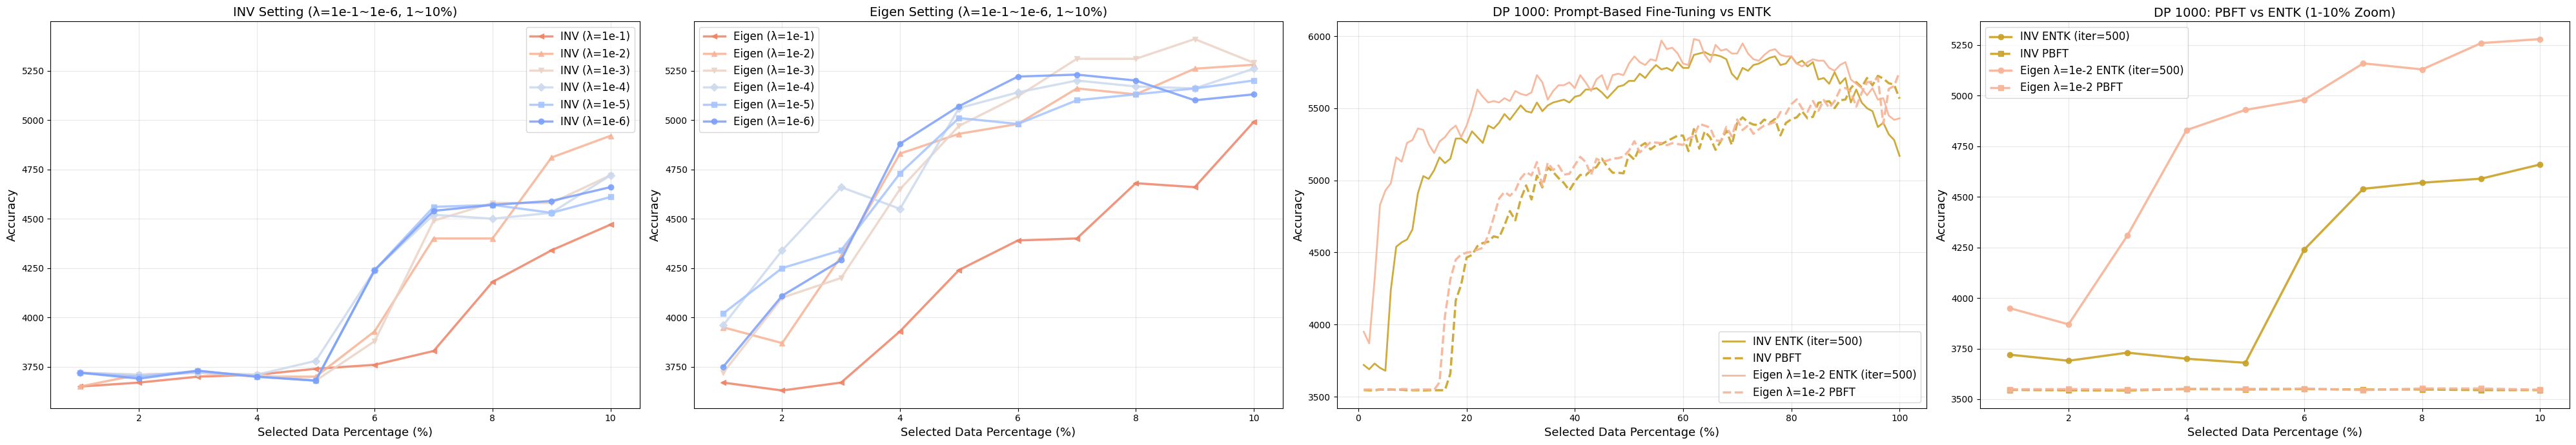

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [3720, 3690, 3730, 3700, 3680, 4240, 4540, 4570, 4590, 4660, 4910, 5030, 5010, 5070, 5160, 5120, 5150, 5290, 5290, 5260, 5340, 5300, 5260, 5380, 5360, 5400, 5460, 5420, 5470, 5520, 5480, 5470, 5540, 5480, 5520, 5540, 5550, 5560, 5540, 5580, 5590, 5630, 5630, 5640, 5610, 5570, 5610, 5650, 5660, 5690, 5690, 5740, 5710, 5760, 5800, 5770, 5780, 5760, 5820, 5780, 5780, 5870, 5880, 5890, 5870, 5870, 5860, 5840, 5740, 5700, 5780, 5760, 5800, 5810, 5830, 5850, 5860, 5800, 5810, 5860, 5810, 5830, 5790, 5820, 5700, 5710, 5670, 5750, 5670, 5710, 5540, 5630, 5540, 5500, 5480, 5370, 5400, 5320, 5280, 5170]
inv_lam1e_5      = [3720, 3700, 3730, 3700, 3680, 4240, 4560, 4570, 4530, 4610, 4880, 5010, 5040, 5070, 5160, 5140, 5160, 5240, 5260, 5280, 5410, 5320, 5260, 5390, 5360, 5370, 5460, 5420, 5460, 5510, 5480, 5470, 5550, 5470, 5520, 5540, 5560, 5560, 5610, 5580, 5610, 5630, 5620, 5620, 5610, 5580, 5640, 5660, 5680, 5700, 5710, 5740, 5720, 5740, 5710, 5790, 5720, 5760, 5790, 5780, 5840, 5870, 5870, 5900, 5870, 5840, 5900, 5840, 5740, 5770, 5780, 5760, 5800, 5810, 5820, 5850, 5860, 5790, 5880, 5870, 5810, 5830, 5790, 5800, 5690, 5720, 5670, 5750, 5670, 5660, 5560, 5610, 5540, 5500, 5490, 5370, 5370, 5320, 5280, 5170]
inv_lam1e_4      = [3720, 3710, 3720, 3710, 3780, 4240, 4520, 4500, 4530, 4720, 4650, 5020, 5100, 5040, 5120, 5210, 5190, 5220, 5210, 5270, 5410, 5320, 5250, 5350, 5390, 5380, 5330, 5410, 5570, 5550, 5480, 5470, 5490, 5510, 5550, 5490, 5580, 5540, 5620, 5650, 5600, 5640, 5620, 5610, 5580, 5610, 5620, 5690, 5670, 5720, 5740, 5740, 5780, 5740, 5690, 5740, 5670, 5750, 5820, 5830, 5800, 5890, 5860, 5860, 5840, 5850, 5900, 5810, 5690, 5810, 5750, 5770, 5860, 5840, 5860, 5850, 5860, 5790, 5810, 5880, 5840, 5840, 5760, 5880, 5700, 5710, 5690, 5690, 5690, 5660, 5630, 5600, 5540, 5390, 5470, 5370, 5370, 5320, 5280, 5170]
inv_lam1e_3      = [3720, 3710, 3720, 3710, 3680, 3880, 4490, 4580, 4580, 4720, 4950, 5080, 5060, 5100, 5130, 5170, 5180, 5220, 5250, 5210, 5240, 5340, 5360, 5290, 5370, 5390, 5380, 5460, 5470, 5420, 5450, 5430, 5480, 5500, 5510, 5530, 5520, 5540, 5560, 5600, 5610, 5600, 5610, 5600, 5620, 5630, 5670, 5690, 5680, 5700, 5760, 5750, 5690, 5730, 5660, 5680, 5880, 5820, 5850, 5800, 5830, 5850, 5790, 5770, 5790, 5800, 5820, 5900, 5830, 5840, 5860, 5810, 5810, 5840, 5890, 5840, 5820, 5840, 5860, 5840, 5870, 5810, 5790, 5720, 5760, 5700, 5740, 5650, 5660, 5690, 5610, 5600, 5610, 5420, 5430, 5370, 5400, 5310, 5270, 5160]
inv_lam1e_2      = [3650, 3710, 3720, 3700, 3700, 3930, 4400, 4400, 4810, 4920, 4920, 4940, 4990, 4950, 5020, 5030, 5150, 5240, 5250, 5330, 5340, 5290, 5320, 5370, 5340, 5390, 5440, 5520, 5470, 5490, 5510, 5520, 5530, 5530, 5590, 5540, 5540, 5590, 5600, 5630, 5690, 5720, 5660, 5630, 5620, 5660, 5690, 5720, 5720, 5670, 5690, 5600, 5630, 5680, 5700, 5700, 5770, 5760, 5720, 5810, 5760, 5800, 5820, 5750, 5750, 5790, 5790, 5730, 5770, 5840, 5820, 5860, 5840, 5860, 5880, 5920, 5820, 5860, 5870, 5890, 5910, 5900, 5810, 5870, 5850, 5790, 5740, 5710, 5690, 5620, 5610, 5520, 5510, 5470, 5530, 5490, 5510, 5390, 5230, 5180]
inv_lam1e_1      = [3650, 3670, 3700, 3710, 3740, 3760, 3830, 4180, 4340, 4470, 4480, 4430, 4830, 4860, 4900, 4900, 4990, 5060, 5090, 5060, 5100, 5230, 5260, 5190, 5270, 5270, 5300, 5370, 5400, 5350, 5370, 5430, 5450, 5420, 5460, 5460, 5570, 5560, 5560, 5520, 5640, 5670, 5590, 5660, 5690, 5700, 5670, 5670, 5640, 5670, 5660, 5650, 5670, 5710, 5700, 5670, 5600, 5600, 5660, 5690, 5650, 5680, 5760, 5750, 5810, 5780, 5820, 5780, 5790, 5860, 5880, 5860, 5840, 5870, 5850, 5880, 5840, 5820, 5810, 5810, 5850, 5780, 5750, 5780, 5730, 5690, 5710, 5690, 5710, 5710, 5660, 5710, 5700, 5680, 5750, 5680, 5610, 5450, 5330, 5300]
eigen_lam1e_6    = [3750, 4110, 4290, 4880, 5070, 5220, 5230, 5200, 5100, 5130, 5110, 5130, 5170, 5340, 5250, 5240, 5260, 5140, 5100, 5030, 4930, 5050, 5110, 5060, 5130, 4880, 4780, 4550, 4090, 3920, 4150, 4560, 4950, 5020, 4930, 5040, 5230, 5340, 5350, 5380, 5420, 5540, 5580, 5560, 5580, 5730, 5800, 5630, 5610, 5670, 5780, 5710, 5590, 5740, 5780, 5760, 5880, 5900, 5870, 5920, 5930, 5920, 5930, 6000, 6010, 6060, 6040, 5930, 5900, 5960, 5970, 5970, 6000, 5970, 5980, 5990, 5870, 5930, 5830, 5860, 5810, 5850, 5930, 5810, 5770, 5790, 5770, 5760, 5740, 5730, 5820, 5660, 5690, 5730, 5660, 5530, 5540, 5410, 5390, 5400]
eigen_lam1e_5    = [4020, 4250, 4340, 4730, 5010, 4980, 5100, 5130, 5160, 5200, 5020, 5180, 5090, 5150, 5220, 5250, 5290, 5220, 5360, 5360, 5130, 5050, 5110, 5060, 4980, 4930, 4790, 4600, 4590, 4410, 4440, 4600, 4800, 5190, 5220, 5340, 5350, 5470, 5480, 5450, 5560, 5670, 5700, 5690, 5620, 5530, 5680, 5680, 5700, 5600, 5710, 5700, 5790, 5760, 5840, 5850, 5840, 5760, 5770, 5910, 5920, 5930, 5900, 5870, 5860, 5850, 5950, 5990, 5920, 5860, 5910, 5860, 5900, 5930, 5970, 5960, 5900, 5930, 5870, 5880, 5800, 5800, 5800, 5880, 5860, 5810, 5800, 5770, 5770, 5740, 5720, 5790, 5670, 5660, 5630, 5560, 5470, 5410, 5370, 5400]
eigen_lam1e_4    = [3960, 4340, 4660, 4550, 5060, 5140, 5200, 5170, 5160, 5260, 5270, 5340, 5310, 5290, 5200, 5320, 5250, 5170, 5260, 5200, 5220, 5120, 5200, 5130, 4880, 5070, 4960, 4740, 4770, 5040, 4870, 5010, 5180, 5080, 5120, 5200, 5330, 5470, 5530, 5510, 5690, 5700, 5610, 5680, 5680, 5670, 5610, 5620, 5630, 5690, 5720, 5640, 5830, 5700, 5620, 5660, 5740, 5770, 5850, 5890, 5910, 5930, 5900, 5990, 5950, 5940, 5960, 5930, 5890, 5920, 5940, 5940, 5990, 5990, 5960, 5990, 5990, 5950, 5940, 5740, 5800, 5840, 5800, 5840, 5790, 5820, 5770, 5770, 5740, 5790, 5730, 5670, 5660, 5690, 5620, 5500, 5530, 5360, 5370, 5400]
eigen_lam1e_3    = [3720, 4100, 4200, 4650, 4970, 5120, 5310, 5310, 5410, 5290, 5250, 5130, 5200, 5250, 5330, 5350, 5340, 5410, 5400, 5450, 5240, 5300, 5210, 5270, 5270, 5330, 5200, 5270, 5310, 5420, 5320, 5350, 5330, 5510, 5390, 5500, 5490, 5520, 5570, 5600, 5550, 5560, 5550, 5600, 5660, 5620, 5670, 5760, 5750, 5860, 5820, 5800, 5800, 5790, 5730, 5830, 5790, 5740, 5770, 5720, 5720, 5780, 5870, 5890, 5920, 5860, 5860, 5840, 5840, 5830, 5900, 5840, 5870, 5830, 5890, 5850, 5850, 5810, 5820, 5840, 5840, 5730, 5810, 5850, 5810, 5820, 5790, 5760, 5750, 5750, 5720, 5720, 5700, 5650, 5640, 5460, 5550, 5370, 5370, 5410]
eigen_lam1e_2    = [3950, 3870, 4310, 4830, 4930, 4980, 5160, 5130, 5260, 5280, 5360, 5350, 5250, 5190, 5270, 5300, 5350, 5380, 5300, 5380, 5490, 5630, 5580, 5540, 5550, 5540, 5570, 5550, 5620, 5600, 5590, 5610, 5730, 5680, 5560, 5620, 5660, 5660, 5680, 5640, 5730, 5680, 5620, 5700, 5730, 5630, 5730, 5740, 5730, 5810, 5860, 5820, 5800, 5840, 5830, 5970, 5910, 5920, 5880, 5810, 5800, 5980, 5970, 5870, 5820, 5940, 5900, 5910, 5880, 5880, 5950, 5880, 5840, 5830, 5870, 5900, 5910, 5870, 5860, 5860, 5810, 5790, 5820, 5840, 5830, 5830, 5780, 5760, 5800, 5820, 5700, 5670, 5640, 5590, 5640, 5560, 5570, 5450, 5420, 5430]
eigen_lam1e_1    = [3670, 3630, 3670, 3930, 4240, 4390, 4400, 4680, 4660, 4990, 4970, 5020, 5130, 5200, 5290, 5290, 5390, 5370, 5400, 5430, 5440, 5490, 5540, 5530, 5520, 5520, 5540, 5540, 5570, 5570, 5540, 5600, 5610, 5650, 5650, 5690, 5590, 5640, 5660, 5720, 5710, 5680, 5700, 5640, 5680, 5740, 5730, 5780, 5800, 5780, 5830, 5810, 5830, 5820, 5790, 5740, 5750, 5780, 5790, 5790, 5710, 5730, 5770, 5740, 5810, 5760, 5760, 5740, 5750, 5740, 5790, 5770, 5800, 5810, 5800, 5770, 5740, 5750, 5750, 5740, 5780, 5740, 5790, 5770, 5830, 5770, 5840, 5810, 5680, 5670, 5710, 5750, 5640, 5690, 5680, 5670, 5610, 5600, 5580, 5480]

# Prediction with random shapley values
r_inv_lam1e_6     = [3260, 3530, 3760, 3990, 4160, 4350, 4240, 4340, 4400, 4510, 4610, 4680, 4750, 4810, 4860, 4840, 4900, 4910, 4820, 4870, 4860, 5010, 4990, 4810, 4820, 4930, 5020, 5050, 4950, 4940, 4970, 4980, 4990, 5220, 5200, 5220, 5250, 5300, 5330, 5200, 5180, 5120, 5180, 5150, 5040, 5100, 5040, 5060, 5070, 5000, 4990, 4910, 4830, 4970, 5020, 5050, 4920, 4920, 4980, 4990, 4990, 5010, 5020, 5100, 5010, 5050, 5060, 5130, 5100, 5080, 5070, 5050, 5090, 5120, 5110, 5180, 5130, 5210, 5170, 5120, 5190, 5210, 5160, 5130, 5140, 5150, 5150, 5160, 5070, 5010, 5120, 5120, 5060, 5120, 5130, 5160, 5110, 5120, 5200, 5170]
r_inv_lam1e_5     = [3260, 3530, 3760, 3990, 4160, 4350, 4240, 4340, 4400, 4510, 4610, 4680, 4750, 4810, 4860, 4840, 4900, 4910, 4820, 4870, 4860, 5010, 4990, 4810, 4820, 4930, 5020, 5050, 4950, 4940, 4970, 4980, 4990, 5220, 5200, 5220, 5250, 5300, 5330, 5200, 5180, 5120, 5180, 5150, 5040, 5100, 5040, 5060, 5070, 5000, 4990, 4910, 4830, 4970, 5020, 5050, 4920, 4920, 4980, 4990, 4990, 5010, 5020, 5100, 5010, 5050, 5060, 5130, 5100, 5080, 5070, 5050, 5090, 5120, 5110, 5180, 5130, 5210, 5170, 5120, 5190, 5210, 5160, 5130, 5140, 5150, 5150, 5160, 5070, 5010, 5120, 5120, 5060, 5120, 5130, 5160, 5110, 5120, 5200, 5170]
r_inv_lam1e_4     = [3260, 3530, 3760, 3970, 4160, 4350, 4240, 4340, 4400, 4510, 4610, 4680, 4750, 4810, 4860, 4840, 4900, 4910, 4820, 4870, 4860, 5010, 4990, 4810, 4820, 4930, 5020, 5050, 4950, 4940, 4970, 4980, 4990, 5220, 5200, 5220, 5250, 5300, 5330, 5200, 5180, 5120, 5180, 5140, 5040, 5100, 5040, 5060, 5070, 5000, 4990, 4910, 4830, 4970, 5020, 5050, 4920, 4920, 4980, 4990, 4990, 5010, 5020, 5100, 5010, 5050, 5060, 5130, 5100, 5080, 5070, 5050, 5090, 5120, 5110, 5180, 5130, 5210, 5170, 5130, 5190, 5210, 5160, 5130, 5140, 5150, 5150, 5160, 5070, 5010, 5120, 5120, 5060, 5120, 5130, 5150, 5100, 5120, 5200, 5170]
r_inv_lam1e_3     = [3260, 3520, 3760, 3960, 4160, 4370, 4250, 4340, 4400, 4520, 4620, 4690, 4750, 4810, 4870, 4840, 4890, 4900, 4820, 4860, 4860, 5000, 4990, 4810, 4810, 4950, 5030, 5050, 4960, 4930, 4960, 4990, 4980, 5230, 5200, 5220, 5270, 5270, 5330, 5210, 5180, 5120, 5170, 5150, 5050, 5100, 5040, 5060, 5090, 5000, 4990, 4900, 4830, 4980, 5030, 5050, 4930, 4920, 4990, 5000, 5010, 5000, 5010, 5100, 5020, 5040, 5060, 5100, 5100, 5090, 5060, 5050, 5090, 5130, 5110, 5170, 5140, 5180, 5180, 5130, 5190, 5200, 5170, 5160, 5140, 5160, 5150, 5160, 5070, 5010, 5130, 5130, 5060, 5130, 5140, 5140, 5100, 5100, 5170, 5160]
r_inv_lam1e_2     = [3260, 3550, 3760, 3960, 4170, 4400, 4280, 4310, 4420, 4550, 4620, 4720, 4790, 4850, 4870, 4890, 4850, 4890, 4830, 4820, 4850, 5000, 4970, 4890, 4790, 4960, 5030, 5080, 4990, 4980, 5000, 5010, 5020, 5270, 5230, 5280, 5260, 5280, 5330, 5230, 5200, 5130, 5160, 5190, 5100, 5110, 5060, 5070, 5090, 5020, 5020, 4960, 4880, 4990, 5040, 5090, 5040, 4950, 4980, 5020, 5050, 5090, 5030, 5100, 5090, 5090, 5070, 5140, 5180, 5130, 5080, 5080, 5090, 5190, 5140, 5190, 5150, 5190, 5210, 5200, 5140, 5140, 5160, 5170, 5190, 5200, 5190, 5160, 5060, 5070, 5110, 5140, 5090, 5090, 5130, 5160, 5130, 5150, 5150, 5180]
r_inv_lam1e_1     = [3260, 3500, 3640, 3840, 4130, 4510, 4370, 4380, 4490, 4590, 4490, 4680, 4790, 4900, 4880, 4970, 5040, 4930, 5010, 4930, 5020, 5070, 5050, 5030, 4960, 5120, 5170, 5070, 5070, 5060, 5120, 5210, 5180, 5280, 5310, 5380, 5380, 5410, 5420, 5400, 5410, 5380, 5360, 5240, 5240, 5300, 5210, 5290, 5280, 5240, 5110, 5130, 5200, 5270, 5330, 5290, 5250, 5340, 5300, 5360, 5350, 5420, 5390, 5400, 5370, 5390, 5420, 5380, 5370, 5320, 5300, 5280, 5260, 5350, 5350, 5320, 5340, 5330, 5360, 5290, 5300, 5330, 5360, 5350, 5350, 5340, 5290, 5280, 5330, 5260, 5280, 5280, 5260, 5210, 5280, 5260, 5290, 5290, 5320, 5300]
r_eigen_lam1e_6   = [3260, 3700, 3860, 4200, 4220, 4190, 4080, 4160, 4300, 4400, 4340, 4390, 4350, 4450, 4570, 4510, 4530, 4440, 4600, 4420, 4550, 4220, 4300, 4140, 3950, 3670, 3560, 3450, 3470, 3560, 3570, 3460, 3570, 3700, 3840, 3980, 4180, 4240, 4260, 4340, 4410, 4420, 4690, 4760, 4680, 4850, 4840, 4820, 4880, 4790, 4750, 4740, 4710, 4900, 4790, 4840, 4760, 4800, 4830, 4990, 5030, 5090, 5040, 5060, 5090, 4990, 4990, 4980, 4990, 5060, 4960, 4990, 4960, 5120, 5020, 5110, 5160, 5110, 5080, 5100, 5220, 5170, 5180, 5200, 5240, 5250, 5100, 5080, 5130, 5140, 5170, 5220, 5230, 5330, 5260, 5340, 5270, 5310, 5410, 5400]
r_eigen_lam1e_5   = [3240, 3680, 3910, 4140, 4190, 4180, 4080, 4160, 4330, 4380, 4330, 4380, 4340, 4480, 4600, 4560, 4520, 4430, 4540, 4400, 4500, 4160, 4280, 4120, 3960, 3640, 3570, 3460, 3460, 3560, 3620, 3530, 3570, 3700, 3790, 3990, 4160, 4240, 4240, 4360, 4410, 4420, 4680, 4770, 4680, 4850, 4830, 4820, 4880, 4790, 4750, 4740, 4710, 4900, 4790, 4840, 4760, 4800, 4830, 4990, 5030, 5090, 5040, 5060, 5080, 4990, 4990, 4980, 4990, 5060, 4960, 4990, 4960, 5120, 5020, 5110, 5160, 5110, 5080, 5100, 5220, 5170, 5180, 5200, 5240, 5250, 5100, 5080, 5130, 5140, 5170, 5220, 5230, 5330, 5260, 5340, 5270, 5310, 5410, 5400]
r_eigen_lam1e_4   = [3270, 3680, 3920, 4130, 4170, 4190, 4080, 4160, 4330, 4370, 4330, 4380, 4340, 4480, 4590, 4560, 4530, 4430, 4540, 4450, 4530, 4170, 4290, 4140, 3970, 3690, 3560, 3670, 3580, 3550, 3770, 3620, 3670, 3850, 3760, 4050, 4140, 4270, 4200, 4440, 4470, 4410, 4720, 4780, 4700, 4880, 4820, 4810, 4890, 4800, 4760, 4750, 4720, 4900, 4790, 4840, 4760, 4800, 4830, 4990, 5030, 5090, 5030, 5070, 5080, 4990, 4990, 4990, 4990, 5070, 4950, 4990, 4960, 5110, 5030, 5110, 5170, 5110, 5080, 5100, 5230, 5170, 5180, 5210, 5250, 5250, 5100, 5080, 5130, 5130, 5170, 5220, 5230, 5330, 5260, 5330, 5270, 5320, 5410, 5400]
r_eigen_lam1e_3   = [3270, 3680, 3930, 4120, 4160, 4200, 4090, 4180, 4330, 4390, 4370, 4380, 4410, 4470, 4600, 4580, 4500, 4480, 4590, 4580, 4540, 4350, 4370, 4330, 4070, 4130, 3950, 3950, 3950, 3870, 3990, 3870, 3880, 3990, 3970, 4140, 4240, 4410, 4290, 4580, 4570, 4530, 4840, 4760, 4710, 4840, 4830, 4910, 4870, 4840, 4790, 4770, 4730, 4870, 4800, 4820, 4780, 4800, 4910, 5010, 5030, 5100, 5020, 5090, 5090, 5030, 5000, 5040, 5010, 5080, 4950, 5010, 4940, 5080, 5020, 5130, 5200, 5120, 5110, 5110, 5240, 5150, 5190, 5200, 5270, 5270, 5100, 5100, 5130, 5100, 5180, 5210, 5240, 5340, 5270, 5340, 5280, 5320, 5410, 5410]
r_eigen_lam1e_2   = [3280, 3680, 3880, 4160, 4160, 4290, 4130, 4290, 4370, 4490, 4490, 4510, 4510, 4650, 4600, 4630, 4710, 4790, 4740, 4870, 4680, 4680, 4770, 4830, 4570, 4630, 4400, 4530, 4550, 4580, 4570, 4510, 4520, 4570, 4620, 4570, 4620, 4850, 4780, 5000, 4960, 4930, 4920, 4920, 4970, 5040, 5030, 5090, 5040, 4970, 4950, 4920, 4850, 4930, 4950, 4970, 4970, 5020, 5040, 5120, 5130, 5120, 5130, 5170, 5180, 5060, 5120, 5120, 5000, 5070, 5060, 5140, 5040, 5120, 5090, 5130, 5200, 5100, 5110, 5160, 5180, 5160, 5190, 5240, 5260, 5270, 5130, 5130, 5140, 5160, 5240, 5150, 5240, 5300, 5290, 5360, 5340, 5340, 5430, 5430]
r_eigen_lam1e_1   = [3240, 3560, 3810, 3990, 4120, 4440, 4260, 4120, 4450, 4560, 4450, 4550, 4720, 4800, 4700, 4800, 4810, 4900, 4950, 4930, 4900, 5030, 5060, 5010, 4950, 5070, 5070, 4980, 4980, 5080, 5060, 5110, 5260, 5360, 5300, 5410, 5350, 5370, 5480, 5410, 5360, 5340, 5370, 5420, 5380, 5350, 5290, 5200, 5190, 5210, 5200, 5240, 5100, 5220, 5290, 5340, 5260, 5270, 5350, 5370, 5450, 5340, 5350, 5350, 5320, 5260, 5270, 5220, 5250, 5320, 5340, 5300, 5250, 5290, 5280, 5310, 5270, 5240, 5240, 5250, 5280, 5240, 5240, 5310, 5270, 5310, 5220, 5230, 5200, 5290, 5280, 5250, 5310, 5370, 5350, 5360, 5370, 5450, 5450, 5480]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [3546, 3544, 3543, 3550, 3548, 3550, 3548, 3548, 3545, 3545, 3545, 3543, 3545, 3545, 3545, 3545, 3660, 4168, 4277, 4465, 4483, 4544, 4566, 4574, 4612, 4603, 4688, 4787, 4723, 4869, 4965, 4868, 5033, 4951, 5090, 5058, 5016, 4981, 4930, 4992, 5038, 5035, 5070, 5093, 5151, 5094, 5053, 5053, 5049, 5180, 5143, 5235, 5259, 5215, 5244, 5252, 5271, 5291, 5310, 5311, 5203, 5356, 5220, 5340, 5298, 5212, 5273, 5346, 5246, 5398, 5437, 5404, 5387, 5384, 5422, 5399, 5426, 5312, 5398, 5424, 5437, 5479, 5430, 5441, 5538, 5545, 5549, 5501, 5555, 5561, 5640, 5681, 5646, 5710, 5659, 5725, 5706, 5674, 5664, 5567]
pbft_eigen_lam1e_2 = [3549, 3550, 3547, 3551, 3551, 3552, 3545, 3553, 3553, 3547, 3550, 3550, 3550, 3547, 3600, 4056, 4314, 4450, 4486, 4499, 4505, 4519, 4532, 4619, 4741, 4874, 4920, 4893, 4930, 5014, 5057, 5035, 5127, 4958, 5123, 5072, 5103, 5040, 5046, 5106, 5163, 5128, 5037, 5150, 5131, 5137, 5152, 5154, 5165, 5206, 5272, 5194, 5230, 5266, 5262, 5259, 5244, 5258, 5252, 5246, 5290, 5307, 5391, 5380, 5366, 5277, 5274, 5371, 5305, 5422, 5349, 5381, 5323, 5354, 5381, 5391, 5405, 5474, 5462, 5528, 5562, 5498, 5476, 5551, 5482, 5557, 5503, 5550, 5629, 5641, 5615, 5511, 5607, 5681, 5684, 5712, 5391, 5634, 5655, 5752]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

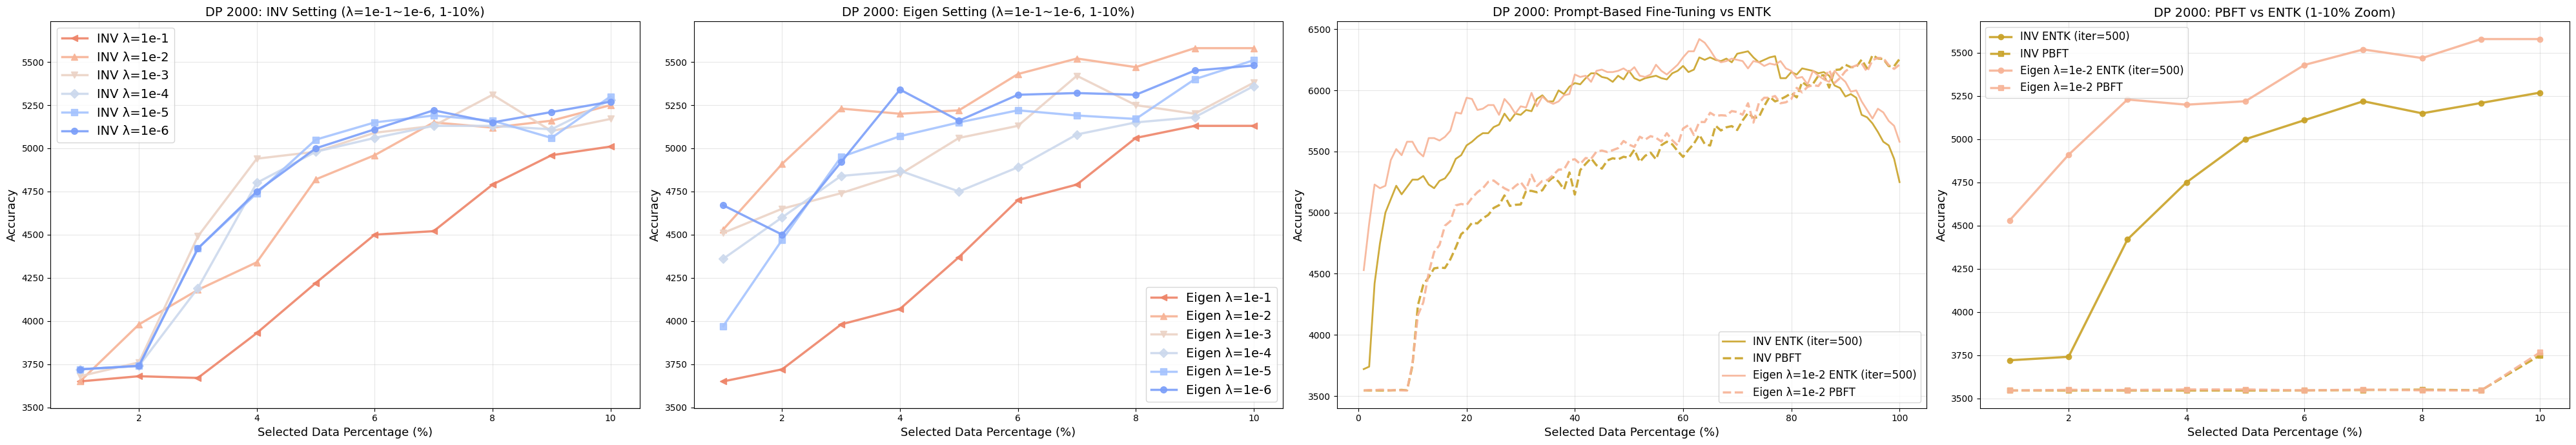

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [3720, 3740, 4420, 4750, 5000, 5110, 5220, 5150, 5210, 5270, 5270, 5300, 5230, 5200, 5260, 5280, 5340, 5440, 5470, 5550, 5580, 5620, 5650, 5650, 5700, 5720, 5810, 5750, 5810, 5800, 5840, 5830, 5930, 5960, 5910, 5910, 6000, 5970, 6030, 6060, 6050, 6100, 6140, 6140, 6110, 6100, 6070, 6120, 6090, 6160, 6100, 6080, 6100, 6110, 6120, 6100, 6090, 6140, 6160, 6200, 6150, 6170, 6270, 6250, 6270, 6250, 6240, 6260, 6230, 6300, 6310, 6320, 6270, 6230, 6250, 6270, 6280, 6100, 6100, 6150, 6130, 6180, 6170, 6160, 6140, 6150, 6120, 6040, 6020, 5950, 5970, 5940, 5800, 5780, 5730, 5660, 5580, 5550, 5440, 5250]
inv_lam1e_5      = [3720, 3740, 4420, 4740, 5050, 5150, 5190, 5160, 5060, 5300, 5260, 5240, 5270, 5220, 5310, 5290, 5300, 5420, 5510, 5610, 5600, 5540, 5610, 5650, 5740, 5730, 5810, 5800, 5820, 5770, 5870, 5850, 5900, 5950, 5900, 5900, 5940, 5970, 5970, 5940, 6070, 6110, 6090, 6130, 6120, 6120, 6090, 6100, 6120, 6090, 6080, 6040, 6100, 6080, 6130, 6060, 6110, 6180, 6150, 6180, 6110, 6170, 6200, 6290, 6240, 6290, 6210, 6240, 6260, 6270, 6280, 6240, 6270, 6330, 6250, 6310, 6300, 6100, 6130, 6150, 6140, 6180, 6180, 6150, 6200, 6140, 6000, 6020, 6010, 5970, 5930, 5880, 5800, 5780, 5790, 5630, 5570, 5550, 5420, 5260] 
inv_lam1e_4      = [3720, 3740, 4190, 4800, 4980, 5060, 5130, 5130, 5110, 5280, 5260, 5200, 5240, 5250, 5230, 5220, 5280, 5410, 5500, 5580, 5580, 5600, 5640, 5660, 5750, 5800, 5740, 5750, 5750, 5790, 5820, 5850, 5870, 5870, 5860, 5900, 5920, 5990, 6010, 6050, 6090, 6120, 6070, 6040, 6130, 6130, 6130, 6120, 6140, 6110, 6060, 6090, 6090, 6080, 6090, 6110, 6120, 6110, 6160, 6150, 6160, 6170, 6240, 6250, 6230, 6180, 6230, 6310, 6260, 6280, 6310, 6300, 6320, 6240, 6250, 6240, 6250, 6210, 6150, 6140, 6160, 6220, 6220, 6150, 6070, 6200, 6020, 6000, 6030, 5980, 5940, 5900, 5830, 5760, 5730, 5680, 5570, 5550, 5420, 5260]      
inv_lam1e_3      = [3680, 3760, 4490, 4940, 4980, 5090, 5130, 5310, 5100, 5170, 5220, 5290, 5290, 5290, 5270, 5260, 5360, 5410, 5480, 5500, 5500, 5610, 5630, 5660, 5700, 5710, 5700, 5690, 5730, 5770, 5790, 5820, 5880, 5930, 5970, 6020, 5970, 5910, 5890, 5940, 6020, 6040, 6080, 6050, 6140, 6070, 6040, 6080, 6090, 6040, 6020, 5990, 5990, 6070, 6130, 6130, 6150, 6190, 6120, 6170, 6140, 6140, 6190, 6160, 6250, 6200, 6220, 6170, 6220, 6200, 6280, 6320, 6330, 6340, 6330, 6350, 6250, 6290, 6250, 6260, 6180, 6110, 6170, 6150, 6210, 6210, 6120, 6030, 6000, 6000, 5890, 5890, 5790, 5760, 5690, 5620, 5640, 5550, 5460, 5260]   
inv_lam1e_2      = [3650, 3980, 4180, 4340, 4820, 4960, 5150, 5120, 5160, 5250, 5230, 5200, 5210, 5290, 5290, 5320, 5530, 5560, 5630, 5610, 5610, 5700, 5750, 5820, 5810, 5820, 5790, 5860, 5850, 5820, 5710, 5750, 5740, 5860, 5840, 5940, 5910, 6030, 6000, 6020, 6060, 6020, 6040, 6060, 6060, 6020, 5980, 6010, 6040, 6060, 6010, 6010, 6040, 6110, 6160, 6110, 6140, 6150, 6150, 6190, 6170, 6200, 6180, 6210, 6190, 6150, 6220, 6200, 6190, 6140, 6200, 6220, 6270, 6280, 6290, 6220, 6240, 6220, 6340, 6260, 6250, 6210, 6170, 6150, 6070, 6000, 6000, 6060, 5960, 5900, 5860, 5840, 5840, 5870, 5740, 5690, 5680, 5540, 5490, 5330] 
inv_lam1e_1      = [3650, 3680, 3670, 3930, 4220, 4500, 4520, 4790, 4960, 5010, 5040, 5070, 5060, 5010, 5100, 5120, 5140, 5140, 5240, 5310, 5310, 5400, 5360, 5440, 5410, 5510, 5480, 5600, 5560, 5610, 5620, 5650, 5690, 5750, 5800, 5800, 5770, 5710, 5750, 5740, 5770, 5830, 5820, 5850, 5930, 5900, 5920, 5930, 5920, 5920, 5920, 6010, 6010, 6010, 6000, 6010, 5990, 6100, 6060, 6010, 6070, 6070, 6070, 6120, 6100, 6140, 6110, 6120, 6070, 6130, 6180, 6190, 6180, 6170, 6130, 6030, 6050, 6060, 6120, 6160, 6130, 6130, 6110, 6110, 6080, 6030, 6020, 5920, 5950, 6010, 5870, 5900, 5890, 5850, 5800, 5710, 5760, 5700, 5650, 5520]
eigen_lam1e_6    = [4670, 4500, 4920, 5340, 5160, 5310, 5320, 5310, 5450, 5480, 5450, 5490, 5570, 5550, 5560, 5700, 5690, 5600, 5630, 5660, 5630, 5470, 5510, 5270, 5220, 5170, 4960, 4700, 4330, 4350, 4480, 4970, 5290, 5560, 5630, 5550, 5820, 5720, 5780, 5750, 5700, 5720, 5810, 5810, 5780, 5750, 5790, 5910, 5930, 5940, 5950, 6190, 6160, 6290, 6250, 6180, 6210, 6200, 6180, 6270, 6190, 6270, 6160, 6210, 6260, 6200, 6170, 6120, 6240, 6170, 6240, 6200, 6190, 6200, 6290, 6230, 6200, 6300, 6200, 6170, 6170, 6160, 6110, 6100, 6070, 6050, 6010, 6000, 5990, 5910, 5930, 5900, 5930, 5960, 5820, 5810, 5810, 5860, 5680, 5560]
eigen_lam1e_5    = [3970, 4470, 4950, 5070, 5150, 5220, 5190, 5170, 5400, 5510, 5420, 5480, 5540, 5470, 5580, 5500, 5520, 5560, 5630, 5730, 5760, 5600, 5490, 5350, 5150, 5140, 5150, 5010, 4960, 4420, 4800, 5070, 5320, 5430, 5550, 5650, 5710, 5750, 5780, 5830, 5770, 5840, 5910, 5870, 5940, 5910, 5940, 5950, 5920, 6010, 6030, 6000, 6060, 6100, 6110, 6080, 6100, 6080, 6170, 6140, 6140, 6160, 6150, 6180, 6220, 6150, 6140, 6170, 6160, 6180, 6230, 6290, 6340, 6250, 6260, 6220, 6170, 6210, 6150, 6160, 6110, 6130, 6190, 6220, 6140, 6040, 6050, 5990, 5960, 5900, 5900, 5850, 5880, 5890, 5780, 5850, 5850, 5800, 5700, 5560]
eigen_lam1e_4    = [4360, 4600, 4840, 4870, 4750, 4890, 5080, 5150, 5180, 5360, 5570, 5490, 5480, 5570, 5580, 5690, 5580, 5580, 5600, 5760, 5560, 5480, 5510, 5340, 5290, 5180, 4970, 4880, 4800, 4830, 5120, 5250, 5290, 5490, 5370, 5540, 5490, 5570, 5640, 5770, 5730, 5710, 5870, 5990, 5970, 5900, 5900, 5870, 6010, 6050, 6040, 6110, 6150, 6130, 6200, 6180, 6090, 6100, 6170, 6200, 6250, 6210, 6240, 6200, 6260, 6290, 6270, 6260, 6290, 6210, 6300, 6230, 6220, 6250, 6220, 6200, 6240, 6190, 6270, 6230, 6220, 6090, 6130, 6160, 6050, 6040, 5980, 6010, 6000, 6030, 6030, 5910, 5870, 5790, 5820, 5800, 5780, 5760, 5690, 5560]
eigen_lam1e_3    = [4510, 4650, 4740, 4850, 5060, 5130, 5420, 5250, 5200, 5380, 5450, 5420, 5630, 5530, 5520, 5590, 5590, 5580, 5630, 5480, 5500, 5490, 5470, 5400, 5490, 5630, 5560, 5660, 5600, 5770, 5640, 5560, 5710, 5640, 5760, 5860, 5930, 5820, 5950, 5970, 5990, 6110, 6070, 6010, 6050, 6050, 6000, 6120, 6020, 6110, 6150, 6120, 6000, 6110, 6180, 6180, 6190, 6230, 6220, 6200, 6190, 6230, 6320, 6270, 6250, 6270, 6200, 6280, 6340, 6340, 6320, 6320, 6330, 6370, 6330, 6300, 6260, 6220, 6260, 6280, 6160, 6100, 6010, 6010, 6050, 6070, 6030, 5990, 5950, 5960, 5970, 5870, 5860, 5830, 5850, 5710, 5830, 5690, 5670, 5560]
eigen_lam1e_2    = [4530, 4910, 5230, 5200, 5220, 5430, 5520, 5470, 5580, 5580, 5500, 5460, 5610, 5610, 5590, 5620, 5670, 5820, 5810, 5940, 5930, 5840, 5850, 5880, 5880, 5800, 5930, 5880, 5810, 5870, 5860, 5980, 5870, 5950, 5910, 5890, 5910, 5960, 5970, 6130, 6110, 6120, 6070, 6160, 6170, 6150, 6150, 6160, 6180, 6150, 6190, 6120, 6110, 6130, 6210, 6160, 6130, 6170, 6210, 6270, 6320, 6320, 6420, 6390, 6330, 6260, 6230, 6240, 6260, 6250, 6240, 6180, 6240, 6230, 6200, 6220, 6210, 6240, 6180, 6160, 6100, 6110, 6050, 6160, 6120, 6090, 6070, 6160, 6110, 6070, 5990, 6000, 5910, 5840, 5770, 5850, 5820, 5750, 5710, 5580]
eigen_lam1e_1    = [3650, 3720, 3980, 4070, 4370, 4700, 4790, 5060, 5130, 5130, 5130, 5020, 5180, 5150, 5190, 5290, 5390, 5400, 5420, 5470, 5580, 5600, 5570, 5530, 5570, 5640, 5640, 5660, 5640, 5650, 5670, 5770, 5770, 5760, 5710, 5790, 5720, 5760, 5920, 5920, 5920, 5890, 5880, 5930, 5900, 6000, 5940, 6010, 6030, 6080, 6090, 6110, 6030, 6030, 6030, 6130, 6100, 6050, 6130, 6120, 6170, 6150, 6170, 6140, 6220, 6200, 6150, 6150, 6150, 6150, 6160, 6130, 6170, 6160, 6200, 6140, 6180, 6180, 6110, 6160, 6190, 6140, 6150, 6120, 6040, 6030, 6000, 5970, 5920, 5980, 5970, 5890, 5930, 5980, 5880, 5900, 5820, 5720, 5730, 5620]

# Prediction with random shapley values
r_inv_lam1e_6     = [3770, 4260, 4430, 4450, 4680, 4760, 4900, 5130, 4920, 4870, 4950, 4860, 4950, 4960, 5120, 5210, 5090, 5100, 5140, 5170, 5200, 5120, 5050, 5070, 5090, 5210, 4990, 5140, 5140, 5230, 5090, 5280, 5110, 5150, 5080, 5200, 5260, 5090, 5130, 5080, 5130, 5220, 5240, 5180, 5240, 5250, 5180, 5190, 5290, 5400, 5370, 5280, 5220, 5240, 5350, 5270, 5190, 5340, 5290, 5360, 5310, 5360, 5360, 5280, 5310, 5300, 5240, 5400, 5240, 5390, 5330, 5390, 5390, 5380, 5290, 5390, 5380, 5380, 5370, 5400, 5410, 5420, 5400, 5390, 5350, 5360, 5350, 5320, 5300, 5330, 5350, 5280, 5380, 5380, 5410, 5340, 5320, 5390, 5280, 5250]
r_inv_lam1e_5     = [3770, 4260, 4430, 4450, 4680, 4760, 4900, 5130, 4930, 4870, 4950, 4860, 4950, 4960, 5120, 5210, 5090, 5100, 5140, 5170, 5200, 5120, 5050, 5070, 5090, 5210, 4980, 5140, 5140, 5230, 5090, 5280, 5110, 5150, 5080, 5200, 5260, 5090, 5130, 5080, 5130, 5220, 5240, 5180, 5240, 5250, 5180, 5190, 5290, 5400, 5380, 5280, 5220, 5240, 5350, 5270, 5190, 5330, 5290, 5360, 5310, 5360, 5360, 5280, 5310, 5300, 5240, 5400, 5240, 5390, 5330, 5390, 5390, 5380, 5290, 5390, 5380, 5380, 5370, 5400, 5410, 5420, 5400, 5390, 5350, 5360, 5350, 5320, 5300, 5330, 5350, 5280, 5380, 5380, 5410, 5340, 5320, 5390, 5280, 5260]
r_inv_lam1e_4     = [3770, 4260, 4430, 4450, 4680, 4760, 4900, 5130, 4930, 4870, 4950, 4860, 4950, 4960, 5120, 5200, 5090, 5100, 5140, 5170, 5200, 5120, 5050, 5080, 5090, 5210, 4980, 5150, 5140, 5230, 5090, 5280, 5110, 5150, 5080, 5200, 5260, 5090, 5130, 5080, 5120, 5220, 5240, 5180, 5240, 5250, 5180, 5190, 5290, 5400, 5380, 5280, 5220, 5240, 5350, 5270, 5190, 5330, 5290, 5360, 5310, 5360, 5360, 5280, 5310, 5290, 5240, 5410, 5240, 5390, 5330, 5390, 5390, 5380, 5290, 5390, 5380, 5380, 5370, 5400, 5410, 5420, 5400, 5390, 5350, 5360, 5350, 5320, 5300, 5330, 5350, 5280, 5380, 5380, 5410, 5340, 5320, 5390, 5280, 5260]   
r_inv_lam1e_3     = [3770, 4260, 4430, 4460, 4680, 4770, 4910, 5130, 4940, 4880, 4950, 4860, 4950, 4960, 5120, 5200, 5080, 5100, 5150, 5170, 5190, 5110, 5060, 5090, 5100, 5210, 4980, 5150, 5140, 5210, 5100, 5270, 5110, 5130, 5090, 5220, 5270, 5070, 5120, 5070, 5110, 5220, 5260, 5190, 5240, 5260, 5180, 5200, 5290, 5400, 5380, 5280, 5220, 5250, 5360, 5270, 5230, 5340, 5290, 5360, 5300, 5350, 5370, 5280, 5310, 5280, 5250, 5400, 5240, 5380, 5320, 5380, 5390, 5390, 5280, 5400, 5380, 5380, 5380, 5410, 5410, 5430, 5390, 5400, 5350, 5360, 5350, 5320, 5300, 5340, 5340, 5260, 5370, 5400, 5420, 5350, 5330, 5390, 5280, 5260] 
r_inv_lam1e_2     = [3770, 4260, 4450, 4450, 4660, 4780, 4910, 5160, 4960, 4910, 4970, 4860, 4940, 5030, 5120, 5230, 5090, 5100, 5140, 5230, 5200, 5120, 5090, 5150, 5130, 5200, 5040, 5160, 5100, 5170, 5180, 5280, 5140, 5140, 5100, 5210, 5250, 5050, 5160, 5110, 5130, 5210, 5240, 5190, 5260, 5280, 5200, 5310, 5310, 5380, 5390, 5290, 5220, 5340, 5350, 5280, 5290, 5380, 5350, 5410, 5300, 5310, 5370, 5330, 5370, 5330, 5330, 5340, 5240, 5400, 5310, 5390, 5410, 5390, 5300, 5380, 5360, 5380, 5420, 5420, 5440, 5430, 5400, 5410, 5400, 5460, 5410, 5360, 5330, 5450, 5410, 5350, 5370, 5470, 5480, 5440, 5410, 5430, 5330, 5330]    
r_inv_lam1e_1     = [3840, 4340, 4460, 4470, 4710, 4740, 4830, 5210, 4970, 5000, 4980, 4940, 4870, 5040, 5150, 5190, 5310, 5170, 5260, 5300, 5250, 5270, 5240, 5310, 5310, 5280, 5320, 5330, 5270, 5310, 5370, 5330, 5260, 5200, 5200, 5240, 5220, 5210, 5160, 5190, 5120, 5230, 5250, 5180, 5300, 5230, 5260, 5240, 5340, 5330, 5440, 5520, 5440, 5450, 5420, 5370, 5400, 5460, 5460, 5500, 5500, 5450, 5480, 5490, 5560, 5520, 5520, 5500, 5460, 5490, 5530, 5500, 5540, 5420, 5480, 5540, 5510, 5550, 5460, 5450, 5460, 5470, 5540, 5500, 5550, 5470, 5560, 5550, 5430, 5430, 5460, 5470, 5450, 5530, 5530, 5510, 5540, 5530, 5550, 5520]                        
r_eigen_lam1e_6   = [3660, 4220, 4370, 4380, 4400, 4570, 4600, 4840, 4690, 4540, 4400, 4400, 4410, 4460, 4390, 4460, 4440, 4290, 4220, 4270, 4220, 4430, 4130, 4060, 4130, 4090, 3880, 3880, 3900, 3680, 3640, 3710, 3960, 4100, 4160, 4310, 4210, 4370, 4500, 4600, 4430, 4480, 4500, 4660, 4600, 4620, 4630, 4550, 4690, 4830, 4960, 4840, 4850, 4940, 4920, 4890, 4900, 4940, 5030, 4890, 4990, 4930, 4880, 4900, 4960, 4990, 5050, 5040, 5010, 4970, 4980, 5180, 5190, 5130, 5170, 5150, 5160, 5330, 5340, 5270, 5240, 5190, 5220, 5310, 5300, 5430, 5350, 5290, 5290, 5330, 5330, 5390, 5400, 5390, 5460, 5480, 5470, 5560, 5590, 5560]
r_eigen_lam1e_5   = [3650, 4220, 4420, 4330, 4430, 4580, 4610, 4810, 4720, 4600, 4410, 4410, 4430, 4460, 4420, 4460, 4480, 4320, 4220, 4240, 4210, 4450, 4140, 4000, 4160, 4150, 3860, 3890, 3870, 3860, 3740, 3720, 3960, 4130, 4180, 4320, 4220, 4370, 4480, 4600, 4430, 4480, 4500, 4660, 4600, 4620, 4630, 4550, 4690, 4830, 4960, 4840, 4850, 4950, 4920, 4890, 4900, 4940, 5030, 4890, 4990, 4930, 4880, 4900, 4960, 4990, 5050, 5040, 5010, 4970, 4980, 5180, 5190, 5130, 5170, 5150, 5160, 5330, 5340, 5270, 5250, 5190, 5220, 5310, 5300, 5430, 5350, 5290, 5290, 5330, 5330, 5390, 5400, 5390, 5460, 5480, 5470, 5560, 5590, 5560]
r_eigen_lam1e_4   = [3640, 4240, 4420, 4340, 4420, 4590, 4610, 4830, 4710, 4610, 4390, 4410, 4420, 4460, 4410, 4460, 4500, 4340, 4250, 4240, 4180, 4440, 4170, 4060, 4120, 4130, 3910, 4020, 3860, 4010, 3850, 3920, 3970, 4100, 4190, 4310, 4270, 4350, 4500, 4620, 4440, 4510, 4510, 4660, 4600, 4630, 4660, 4570, 4690, 4840, 4960, 4830, 4850, 4960, 4910, 4910, 4880, 4930, 5030, 4890, 4990, 4920, 4870, 4910, 4970, 4990, 5040, 5040, 5010, 4970, 4990, 5180, 5190, 5150, 5180, 5160, 5160, 5330, 5340, 5280, 5270, 5180, 5220, 5320, 5290, 5430, 5350, 5290, 5290, 5330, 5330, 5390, 5400, 5390, 5460, 5480, 5480, 5560, 5590, 5560]
r_eigen_lam1e_3   = [3650, 4240, 4430, 4350, 4410, 4600, 4600, 4840, 4700, 4630, 4420, 4420, 4480, 4460, 4420, 4440, 4490, 4410, 4340, 4280, 4220, 4380, 4090, 4180, 4140, 4310, 4130, 4150, 4210, 4320, 4270, 4310, 4380, 4380, 4420, 4430, 4390, 4500, 4580, 4660, 4540, 4620, 4680, 4700, 4670, 4630, 4690, 4610, 4780, 4890, 4950, 4910, 4860, 4910, 4900, 4920, 4920, 5020, 5010, 4940, 5000, 4970, 4940, 4950, 5010, 4980, 5040, 5060, 5040, 5000, 4990, 5200, 5180, 5180, 5180, 5180, 5200, 5340, 5350, 5270, 5260, 5190, 5240, 5310, 5310, 5410, 5330, 5300, 5270, 5330, 5340, 5390, 5400, 5420, 5470, 5480, 5480, 5560, 5580, 5560]
r_eigen_lam1e_2   = [3670, 4210, 4410, 4390, 4430, 4640, 4640, 4880, 4850, 4750, 4630, 4540, 4630, 4660, 4670, 4570, 4740, 4750, 4680, 4590, 4680, 4660, 4640, 4630, 4510, 4710, 4620, 4590, 4630, 4700, 4820, 4790, 4780, 4770, 4780, 4800, 4790, 4970, 5000, 4970, 4800, 4880, 5120, 4960, 4950, 4950, 4930, 4960, 4990, 4960, 5040, 5060, 5060, 5010, 5060, 5090, 5020, 5070, 5060, 5060, 5150, 5040, 5020, 5020, 5090, 5060, 5150, 5120, 5140, 5050, 5110, 5300, 5190, 5260, 5220, 5200, 5300, 5370, 5410, 5310, 5350, 5280, 5340, 5320, 5290, 5400, 5340, 5290, 5350, 5370, 5380, 5460, 5480, 5500, 5480, 5480, 5510, 5540, 5570, 5580]
r_eigen_lam1e_1   = [3780, 4330, 4380, 4520, 4630, 4740, 4750, 5100, 4970, 4880, 4910, 4940, 4920, 5010, 5120, 5190, 5260, 5290, 5270, 5170, 5130, 5070, 5120, 5150, 5170, 5180, 5220, 5130, 5190, 5250, 5240, 5230, 5280, 5220, 5170, 5220, 5230, 5290, 5270, 5250, 5150, 5160, 5120, 5070, 5100, 5090, 5050, 5080, 5200, 5250, 5270, 5270, 5240, 5330, 5230, 5240, 5310, 5300, 5260, 5310, 5320, 5410, 5390, 5380, 5430, 5400, 5340, 5280, 5380, 5440, 5450, 5430, 5430, 5460, 5390, 5430, 5450, 5540, 5520, 5500, 5520, 5480, 5560, 5430, 5500, 5560, 5550, 5570, 5560, 5510, 5460, 5530, 5560, 5500, 5570, 5570, 5580, 5600, 5660, 5620]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [3545, 3545, 3545, 3545, 3545, 3545, 3548, 3550, 3546, 3749, 4240, 4410, 4471, 4544, 4551, 4547, 4618, 4715, 4824, 4860, 4917, 4912, 4954, 4981, 5038, 5061, 5141, 5055, 5064, 5067, 5179, 5178, 5167, 5183, 5252, 5291, 5253, 5190, 5329, 5148, 5348, 5399, 5445, 5388, 5360, 5427, 5445, 5436, 5457, 5449, 5515, 5415, 5465, 5491, 5436, 5552, 5580, 5559, 5504, 5456, 5514, 5564, 5637, 5562, 5549, 5711, 5672, 5698, 5708, 5676, 5754, 5815, 5777, 5780, 5872, 5948, 5910, 5927, 5950, 5977, 5943, 6069, 6036, 6053, 6120, 6124, 6023, 6167, 6171, 6210, 6190, 6191, 6252, 6180, 6289, 6261, 6257, 6199, 6198, 6257]
pbft_eigen_lam1e_2 = [3545, 3549, 3548, 3551, 3551, 3546, 3550, 3546, 3545, 3766, 4161, 4266, 4506, 4678, 4735, 4893, 4930, 5059, 5071, 5062, 5121, 5167, 5199, 5252, 5263, 5229, 5199, 5177, 5217, 5250, 5190, 5310, 5218, 5260, 5268, 5307, 5352, 5353, 5428, 5437, 5398, 5447, 5440, 5499, 5508, 5496, 5511, 5528, 5586, 5557, 5538, 5621, 5597, 5626, 5612, 5582, 5650, 5592, 5550, 5688, 5716, 5635, 5742, 5741, 5817, 5791, 5797, 5794, 5831, 5823, 5801, 5895, 5737, 5896, 5940, 5940, 5954, 5895, 5903, 5929, 6021, 5984, 6029, 6043, 6036, 6095, 6168, 6061, 6101, 6157, 6187, 6204, 6222, 6153, 6248, 6266, 6264, 6207, 6176, 6211]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 red -> 1e-6 blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_left = axes[0]

plot_percent = selected_dp_percent[:10]
inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

# Shared y-axis range for (1,1) and (1,2)
shared_series = []
for data, _, _ in inv_lambda_configs + eigen_lambda_configs:
    if data is not None:
        shared_series.extend(data[:10])

if shared_series:
    y_min, y_max = min(shared_series), max(shared_series)
    y_pad = max(20, (y_max - y_min) * 0.08)
else:
    y_min, y_max, y_pad = 0, 1, 0

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(plot_percent, data[:10],
                     color=lambda_colors[i], linewidth=2.5, linestyle='-',
                     marker=marker, markersize=7,
                     label=f'INV λ={lam_label}', alpha=0.9)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)
ax_left.set_xlim(0.5, 10.5)
if shared_series:
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,2): Eigen setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_middle = axes[1]

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(plot_percent, data[:10],
                       color=lambda_colors[i], linewidth=2.5, linestyle='-',
                       marker=marker, markersize=7,
                       label=f'Eigen λ={lam_label}', alpha=0.9)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)
ax_middle.set_xlim(0.5, 10.5)
if shared_series:
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

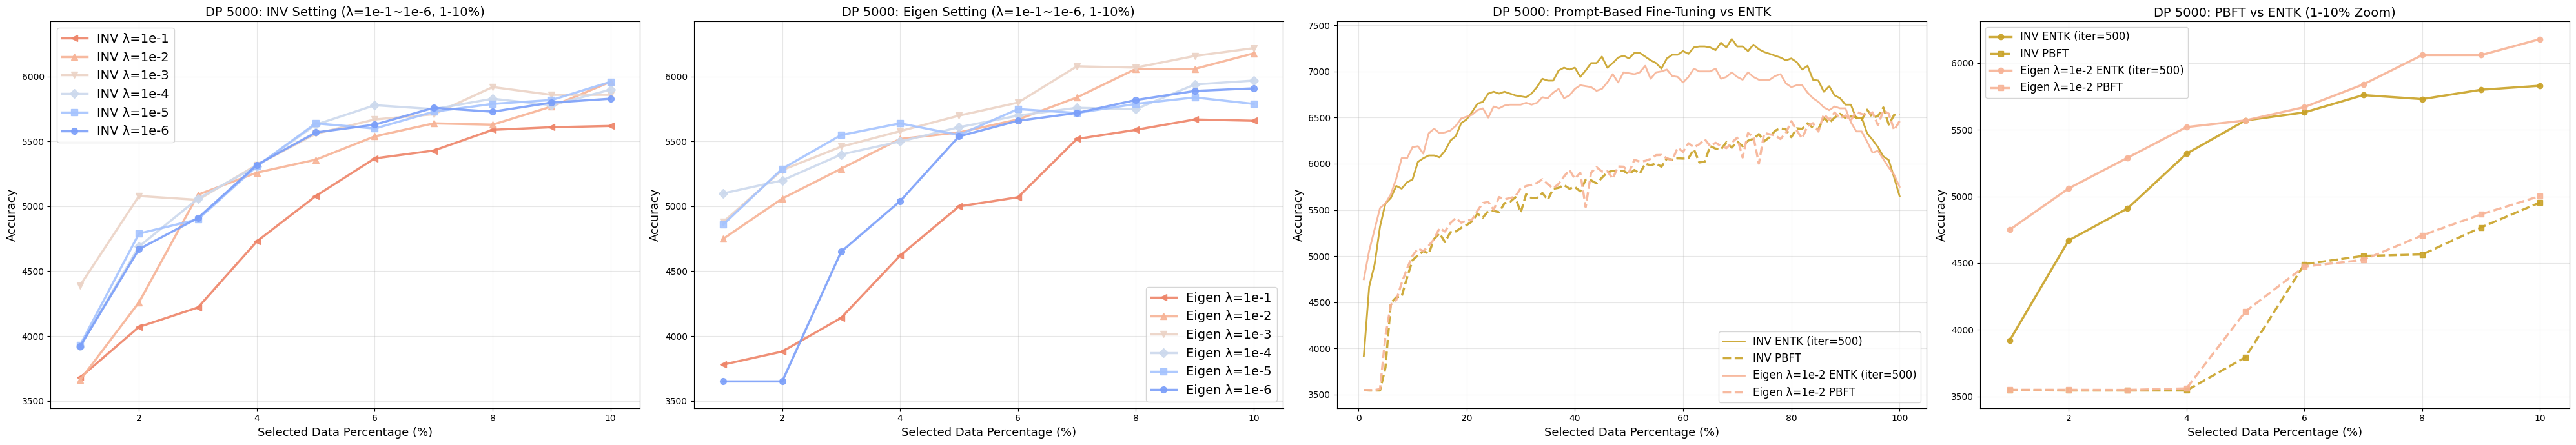

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [3920, 4670, 4910, 5320, 5570, 5630, 5760, 5730, 5800, 5830, 6020, 6060, 6090, 6090, 6070, 6140, 6250, 6300, 6440, 6480, 6560, 6650, 6670, 6760, 6780, 6760, 6780, 6760, 6740, 6730, 6720, 6760, 6830, 6920, 6900, 6900, 7010, 7040, 7020, 7040, 6940, 7010, 7090, 7090, 7160, 7040, 7090, 7150, 7170, 7140, 7200, 7200, 7160, 7120, 7090, 7030, 7140, 7180, 7180, 7220, 7190, 7260, 7270, 7270, 7260, 7230, 7310, 7260, 7350, 7270, 7270, 7220, 7290, 7240, 7210, 7190, 7170, 7150, 7120, 7140, 7100, 7020, 7060, 6910, 6900, 6780, 6840, 6740, 6710, 6640, 6640, 6490, 6500, 6330, 6260, 6180, 6080, 6040, 5850, 5650]
inv_lam1e_5      = [3930, 4790, 4900, 5310, 5640, 5600, 5730, 5790, 5820, 5960, 6020, 6090, 6120, 6070, 6150, 6210, 6330, 6280, 6380, 6430, 6540, 6650, 6650, 6740, 6630, 6680, 6750, 6770, 6710, 6740, 6750, 6750, 6810, 6810, 6880, 6960, 6950, 7020, 7020, 7000, 6990, 7010, 7050, 7120, 7080, 7150, 7120, 7150, 7210, 7170, 7180, 7160, 7190, 7060, 7100, 7110, 7160, 7150, 7190, 7200, 7250, 7260, 7270, 7240, 7310, 7280, 7270, 7260, 7250, 7270, 7230, 7200, 7290, 7250, 7190, 7180, 7110, 7170, 7130, 7140, 7080, 6940, 7030, 6980, 6900, 6840, 6820, 6770, 6750, 6610, 6610, 6490, 6520, 6300, 6230, 6140, 6100, 6010, 5850, 5650]    
inv_lam1e_4      = [3920, 4690, 5060, 5310, 5630, 5780, 5750, 5830, 5780, 5900, 6080, 5950, 6070, 6170, 6250, 6260, 6270, 6340, 6380, 6470, 6460, 6550, 6580, 6540, 6620, 6690, 6730, 6850, 6870, 6780, 6790, 6810, 6890, 6900, 6960, 6940, 6970, 6990, 7020, 7040, 7040, 7040, 7070, 7040, 7100, 6980, 7080, 7070, 7100, 7110, 7130, 7240, 7180, 7110, 7080, 7100, 7090, 7170, 7180, 7190, 7230, 7230, 7200, 7290, 7260, 7240, 7300, 7330, 7260, 7350, 7280, 7160, 7190, 7240, 7140, 7130, 7090, 7110, 7150, 7060, 7100, 7080, 7030, 7050, 6960, 6940, 6770, 6750, 6690, 6710, 6610, 6570, 6510, 6440, 6240, 6200, 6120, 6080, 5870, 5660]  
inv_lam1e_3      = [4390, 5080, 5050, 5320, 5560, 5670, 5710, 5920, 5860, 5860, 5980, 6100, 6110, 6150, 6140, 6280, 6360, 6350, 6380, 6390, 6500, 6520, 6540, 6660, 6660, 6750, 6810, 6780, 6810, 6830, 6850, 6890, 6930, 7010, 7020, 6970, 6900, 6950, 7010, 6970, 6970, 6980, 6930, 6990, 6950, 6950, 7000, 7060, 7080, 7110, 7100, 7160, 7140, 7150, 7180, 7210, 7220, 7190, 7200, 7170, 7180, 7180, 7180, 7210, 7200, 7240, 7210, 7150, 7150, 7130, 7090, 7130, 7180, 7190, 7270, 7240, 7160, 7140, 7130, 7150, 7080, 7080, 7030, 6980, 6930, 6890, 6860, 6790, 6760, 6670, 6620, 6510, 6450, 6390, 6300, 6240, 6120, 5910, 5890, 5640]    
inv_lam1e_2      = [3660, 4260, 5090, 5260, 5360, 5540, 5640, 5630, 5770, 5960, 6020, 5990, 6100, 6230, 6240, 6270, 6480, 6430, 6510, 6530, 6570, 6620, 6590, 6620, 6680, 6660, 6710, 6720, 6760, 6790, 6720, 6860, 6810, 6920, 6930, 6880, 6970, 6900, 6940, 6990, 7040, 7010, 6980, 7010, 7070, 7090, 7140, 7130, 7150, 7090, 7160, 7170, 7200, 7230, 7200, 7190, 7200, 7210, 7200, 7200, 7200, 7220, 7150, 7270, 7220, 7250, 7260, 7260, 7240, 7200, 7230, 7260, 7190, 7230, 7200, 7230, 7210, 7090, 7130, 7040, 7090, 7040, 6970, 7000, 7020, 7010, 6890, 6850, 6800, 6630, 6630, 6520, 6430, 6310, 6280, 6180, 6110, 6000, 5840, 5600]   
inv_lam1e_1      = [3680, 4070, 4220, 4730, 5080, 5370, 5430, 5590, 5610, 5620, 5770, 5750, 5900, 5800, 5910, 5930, 5910, 6010, 6010, 6060, 6150, 6130, 6210, 6310, 6330, 6420, 6440, 6500, 6460, 6500, 6620, 6610, 6600, 6630, 6650, 6680, 6640, 6690, 6680, 6720, 6740, 6740, 6700, 6710, 6700, 6680, 6720, 6750, 6750, 6750, 6860, 6820, 6800, 6860, 6860, 6870, 6950, 6920, 6920, 6920, 6970, 6920, 6930, 6980, 6930, 6940, 7050, 7030, 7010, 7030, 7030, 7040, 7050, 7090, 7090, 7100, 7020, 7100, 7070, 7030, 6950, 6950, 6960, 6930, 6960, 6890, 6840, 6840, 6820, 6760, 6740, 6610, 6560, 6430, 6370, 6310, 6200, 6010, 5860, 5690]       
eigen_lam1e_6    = [3650, 3650, 4650, 5040, 5540, 5660, 5720, 5820, 5890, 5910, 5980, 6050, 6060, 5950, 5940, 5950, 5750, 5660, 5780, 5600, 5700, 5390, 5530, 5480, 5390, 5350, 5000, 4690, 4430, 3980, 4620, 4820, 5200, 5350, 5470, 5590, 5610, 5800, 6070, 6200, 6280, 6300, 6430, 6490, 6500, 6540, 6510, 6480, 6530, 6500, 6510, 6570, 6550, 6650, 6590, 6600, 6580, 6490, 6600, 6560, 6540, 6550, 6480, 6490, 6480, 6450, 6400, 6440, 6460, 6480, 6480, 6550, 6570, 6590, 6500, 6510, 6600, 6490, 6500, 6520, 6570, 6550, 6480, 6390, 6340, 6390, 6300, 6420, 6320, 6320, 6230, 6290, 6180, 6170, 6150, 6060, 5900, 5920, 5760, 5720]
eigen_lam1e_5    = [4860, 5290, 5550, 5640, 5550, 5750, 5720, 5790, 5840, 5790, 5850, 5890, 5930, 5970, 5920, 6020, 6110, 5980, 6030, 5980, 5950, 5870, 5620, 5630, 5470, 5180, 5190, 5010, 4500, 4520, 4720, 5220, 5430, 5740, 5720, 5850, 6030, 6030, 6250, 6280, 6350, 6360, 6330, 6420, 6430, 6490, 6390, 6620, 6630, 6690, 6580, 6460, 6590, 6550, 6730, 6680, 6650, 6760, 6810, 6840, 6790, 6760, 6730, 6870, 6810, 6820, 6800, 6780, 6730, 6700, 6700, 6770, 6700, 6700, 6610, 6600, 6610, 6630, 6580, 6610, 6550, 6630, 6640, 6590, 6550, 6540, 6420, 6390, 6350, 6440, 6330, 6340, 6330, 6220, 6140, 6050, 5970, 5920, 5800, 5720]
eigen_lam1e_4    = [5100, 5200, 5400, 5500, 5610, 5700, 5760, 5750, 5940, 5970, 6050, 6190, 6210, 6140, 6160, 6170, 6130, 6190, 6020, 6080, 5900, 6080, 5900, 5710, 5660, 5490, 5590, 5430, 5580, 5590, 5620, 5520, 5820, 6050, 6050, 6120, 6130, 6410, 6450, 6500, 6440, 6430, 6520, 6510, 6590, 6590, 6600, 6800, 6810, 6690, 6630, 6760, 6560, 6680, 6690, 6690, 6680, 6810, 6780, 6770, 6800, 6810, 6860, 6860, 6720, 6780, 6740, 6780, 6840, 6760, 6760, 6860, 6810, 6660, 6660, 6670, 6700, 6710, 6630, 6610, 6650, 6590, 6580, 6520, 6490, 6460, 6490, 6510, 6460, 6460, 6370, 6340, 6260, 6290, 6260, 6100, 6010, 5870, 5800, 5720]
eigen_lam1e_3    = [4880, 5280, 5460, 5580, 5700, 5800, 6080, 6070, 6160, 6220, 6200, 6200, 6260, 6280, 6330, 6210, 6300, 6400, 6390, 6410, 6280, 6360, 6250, 6330, 6300, 6130, 6150, 6110, 6150, 6210, 6270, 6150, 6190, 6240, 6450, 6450, 6370, 6580, 6550, 6680, 6730, 6590, 6620, 6580, 6580, 6780, 6780, 6800, 6740, 6790, 6780, 6830, 6810, 6800, 6960, 6930, 6860, 6860, 6840, 6920, 6890, 6840, 6810, 6810, 6910, 6890, 6900, 6880, 6880, 6880, 6890, 6910, 6850, 6870, 6870, 6850, 6770, 6730, 6760, 6750, 6710, 6750, 6700, 6720, 6640, 6600, 6580, 6490, 6510, 6370, 6420, 6320, 6330, 6250, 6170, 6100, 6020, 5880, 5810, 5720]
eigen_lam1e_2    = [4750, 5060, 5290, 5520, 5570, 5670, 5840, 6060, 6060, 6180, 6190, 6110, 6330, 6380, 6330, 6340, 6360, 6410, 6490, 6510, 6530, 6580, 6600, 6500, 6620, 6600, 6630, 6640, 6640, 6640, 6660, 6640, 6660, 6720, 6710, 6770, 6810, 6710, 6740, 6810, 6850, 6840, 6830, 6790, 6810, 6880, 6970, 6880, 6990, 6980, 6970, 6990, 7060, 6920, 6990, 7000, 7020, 6950, 6940, 6880, 6940, 7030, 7000, 7000, 7000, 7030, 6920, 6940, 6990, 6940, 6910, 6990, 6940, 6910, 6910, 6910, 6950, 6970, 6870, 6830, 6850, 6850, 6770, 6710, 6670, 6610, 6580, 6620, 6600, 6600, 6450, 6350, 6350, 6240, 6120, 6140, 6050, 5960, 5880, 5750]
eigen_lam1e_1    = [3780, 3880, 4140, 4620, 5000, 5070, 5520, 5590, 5670, 5660, 5780, 5850, 5930, 5950, 6000, 6060, 6070, 6140, 6250, 6180, 6160, 6340, 6370, 6320, 6380, 6380, 6410, 6450, 6420, 6500, 6570, 6590, 6590, 6610, 6640, 6640, 6690, 6700, 6750, 6770, 6790, 6750, 6670, 6690, 6740, 6730, 6810, 6760, 6790, 6740, 6750, 6770, 6780, 6810, 6830, 6850, 6860, 6880, 6880, 6940, 6890, 6890, 6900, 6890, 6860, 6910, 6910, 6920, 6890, 6920, 6940, 6930, 6890, 6890, 6910, 6930, 6830, 6790, 6810, 6860, 6900, 6860, 6850, 6810, 6760, 6730, 6720, 6690, 6740, 6650, 6500, 6420, 6330, 6280, 6240, 6170, 6080, 5950, 5870, 5760]

# Prediction with random shapley values
r_inv_lam1e_6     = [4300, 4280, 4540, 4670, 4640, 4800, 4860, 4850, 5000, 5080, 5040, 5050, 5160, 5140, 5180, 5260, 5250, 5260, 5320, 5290, 5210, 5210, 5180, 5190, 5220, 5250, 5260, 5280, 5420, 5330, 5230, 5330, 5290, 5300, 5210, 5230, 5200, 5270, 5230, 5230, 5230, 5280, 5300, 5250, 5260, 5370, 5340, 5320, 5340, 5260, 5230, 5280, 5300, 5360, 5310, 5270, 5310, 5320, 5180, 5190, 5280, 5330, 5320, 5420, 5440, 5380, 5340, 5280, 5450, 5440, 5390, 5410, 5410, 5380, 5350, 5510, 5400, 5320, 5390, 5400, 5470, 5370, 5420, 5420, 5440, 5470, 5470, 5520, 5530, 5580, 5560, 5600, 5650, 5540, 5560, 5610, 5620, 5670, 5610, 5650]
r_inv_lam1e_5     = [4300, 4280, 4540, 4670, 4640, 4800, 4860, 4850, 5000, 5080, 5040, 5050, 5160, 5140, 5180, 5260, 5250, 5260, 5320, 5290, 5210, 5210, 5180, 5190, 5220, 5250, 5260, 5280, 5420, 5330, 5230, 5340, 5290, 5300, 5210, 5230, 5200, 5270, 5230, 5230, 5230, 5280, 5300, 5250, 5260, 5370, 5340, 5320, 5340, 5260, 5230, 5280, 5300, 5360, 5310, 5270, 5310, 5320, 5180, 5190, 5280, 5330, 5320, 5420, 5440, 5380, 5340, 5280, 5450, 5440, 5390, 5410, 5410, 5380, 5350, 5510, 5400, 5320, 5390, 5400, 5470, 5370, 5420, 5420, 5440, 5470, 5470, 5520, 5530, 5580, 5560, 5600, 5650, 5540, 5560, 5610, 5620, 5670, 5610, 5650] 
r_inv_lam1e_4     = [4300, 4280, 4540, 4670, 4640, 4800, 4860, 4850, 5000, 5080, 5040, 5050, 5160, 5140, 5190, 5260, 5250, 5260, 5320, 5290, 5210, 5210, 5190, 5190, 5220, 5250, 5260, 5280, 5420, 5330, 5230, 5340, 5290, 5300, 5220, 5230, 5200, 5270, 5230, 5230, 5230, 5290, 5300, 5250, 5260, 5370, 5340, 5320, 5340, 5260, 5230, 5280, 5300, 5360, 5310, 5270, 5310, 5320, 5180, 5200, 5280, 5330, 5320, 5420, 5440, 5380, 5340, 5280, 5450, 5440, 5390, 5410, 5410, 5380, 5350, 5510, 5410, 5320, 5390, 5400, 5470, 5370, 5420, 5420, 5440, 5470, 5470, 5520, 5530, 5580, 5560, 5600, 5650, 5550, 5570, 5610, 5620, 5670, 5610, 5660] 
r_inv_lam1e_3     = [4310, 4280, 4540, 4670, 4640, 4800, 4850, 4850, 5010, 5080, 5040, 5050, 5150, 5140, 5190, 5260, 5240, 5260, 5320, 5300, 5210, 5210, 5180, 5210, 5220, 5250, 5240, 5280, 5420, 5330, 5250, 5330, 5290, 5300, 5220, 5240, 5210, 5260, 5220, 5240, 5240, 5300, 5290, 5250, 5280, 5360, 5340, 5330, 5370, 5280, 5230, 5290, 5310, 5370, 5330, 5250, 5330, 5330, 5170, 5220, 5280, 5360, 5320, 5430, 5440, 5400, 5340, 5300, 5450, 5440, 5390, 5430, 5420, 5410, 5380, 5520, 5400, 5320, 5410, 5390, 5460, 5370, 5430, 5420, 5450, 5470, 5480, 5530, 5530, 5580, 5570, 5610, 5640, 5550, 5580, 5610, 5620, 5680, 5610, 5640] 
r_inv_lam1e_2     = [4300, 4310, 4560, 4660, 4720, 4870, 4850, 4890, 5030, 5090, 5080, 5090, 5200, 5170, 5230, 5280, 5300, 5210, 5260, 5290, 5210, 5220, 5200, 5220, 5260, 5250, 5210, 5320, 5410, 5310, 5350, 5260, 5230, 5350, 5200, 5250, 5200, 5210, 5270, 5320, 5260, 5370, 5360, 5320, 5310, 5330, 5360, 5320, 5320, 5350, 5230, 5320, 5370, 5360, 5380, 5300, 5330, 5360, 5250, 5310, 5340, 5390, 5430, 5450, 5450, 5440, 5490, 5400, 5490, 5520, 5410, 5470, 5480, 5410, 5450, 5490, 5470, 5430, 5430, 5440, 5450, 5410, 5430, 5450, 5460, 5550, 5600, 5550, 5570, 5600, 5620, 5660, 5620, 5600, 5610, 5600, 5660, 5660, 5620, 5600] 
r_inv_lam1e_1     = [4400, 4420, 4580, 4700, 4810, 4860, 5050, 5010, 5070, 5100, 5210, 5250, 5230, 5200, 5290, 5430, 5380, 5270, 5330, 5340, 5320, 5260, 5290, 5320, 5290, 5300, 5310, 5330, 5410, 5360, 5310, 5360, 5370, 5380, 5360, 5390, 5350, 5300, 5220, 5380, 5420, 5390, 5430, 5450, 5470, 5590, 5560, 5490, 5470, 5470, 5460, 5490, 5500, 5490, 5420, 5450, 5460, 5590, 5540, 5550, 5540, 5580, 5540, 5560, 5650, 5520, 5500, 5570, 5560, 5520, 5520, 5510, 5540, 5530, 5580, 5610, 5560, 5520, 5540, 5490, 5590, 5530, 5570, 5590, 5630, 5660, 5710, 5690, 5740, 5760, 5720, 5740, 5780, 5840, 5780, 5640, 5670, 5650, 5690, 5690]  
r_eigen_lam1e_6   = [4290, 4170, 4370, 4370, 4380, 4450, 4360, 4420, 4610, 4670, 4640, 4480, 4760, 4630, 4710, 4790, 4520, 4590, 4480, 4460, 4490, 4370, 4220, 4300, 4080, 3990, 3810, 3820, 3840, 3490, 3610, 3760, 3740, 3970, 3990, 4100, 4170, 4280, 4320, 4310, 4350, 4550, 4650, 4640, 4700, 4780, 4850, 4860, 4890, 4900, 5050, 5050, 5030, 5180, 5170, 5090, 5260, 5140, 5180, 5120, 5190, 5270, 5330, 5330, 5380, 5430, 5480, 5560, 5590, 5570, 5370, 5440, 5530, 5570, 5470, 5570, 5490, 5460, 5510, 5490, 5540, 5500, 5480, 5480, 5530, 5560, 5580, 5510, 5550, 5650, 5590, 5700, 5650, 5660, 5660, 5640, 5760, 5680, 5720, 5720]
r_eigen_lam1e_5   = [4240, 4180, 4390, 4440, 4340, 4480, 4360, 4500, 4620, 4710, 4650, 4510, 4700, 4660, 4680, 4820, 4560, 4560, 4480, 4490, 4460, 4410, 4200, 4300, 4050, 4000, 3840, 3830, 3910, 3600, 3670, 3790, 3740, 3950, 3980, 4110, 4180, 4280, 4300, 4320, 4360, 4540, 4660, 4640, 4700, 4780, 4850, 4860, 4870, 4900, 5050, 5050, 5030, 5190, 5170, 5090, 5260, 5140, 5170, 5120, 5190, 5270, 5330, 5330, 5380, 5430, 5480, 5560, 5590, 5570, 5370, 5450, 5530, 5570, 5470, 5570, 5490, 5460, 5510, 5500, 5540, 5500, 5480, 5480, 5530, 5560, 5580, 5500, 5550, 5650, 5590, 5700, 5650, 5660, 5660, 5640, 5760, 5680, 5720, 5720]
r_eigen_lam1e_4   = [4240, 4170, 4390, 4440, 4350, 4480, 4380, 4500, 4620, 4710, 4620, 4530, 4710, 4650, 4690, 4850, 4550, 4560, 4460, 4480, 4480, 4440, 4230, 4350, 4090, 4150, 3930, 4060, 4120, 3880, 3940, 4070, 3900, 4100, 4060, 4240, 4190, 4310, 4350, 4370, 4380, 4570, 4650, 4650, 4700, 4780, 4850, 4840, 4880, 4920, 5060, 5050, 5040, 5170, 5170, 5090, 5270, 5150, 5160, 5120, 5190, 5290, 5300, 5330, 5390, 5430, 5480, 5560, 5590, 5570, 5380, 5450, 5530, 5580, 5470, 5570, 5490, 5460, 5510, 5500, 5560, 5530, 5490, 5480, 5540, 5570, 5590, 5500, 5550, 5650, 5590, 5700, 5650, 5660, 5660, 5650, 5760, 5680, 5720, 5720]
r_eigen_lam1e_3   = [4240, 4180, 4380, 4470, 4340, 4480, 4420, 4500, 4650, 4740, 4670, 4530, 4770, 4670, 4790, 4890, 4690, 4720, 4580, 4600, 4610, 4620, 4450, 4600, 4490, 4330, 4490, 4470, 4500, 4440, 4570, 4540, 4430, 4400, 4300, 4440, 4430, 4530, 4400, 4500, 4580, 4650, 4650, 4770, 4860, 4760, 4910, 4840, 4970, 4980, 5140, 5110, 5040, 5140, 5160, 5120, 5280, 5170, 5250, 5100, 5210, 5310, 5280, 5290, 5400, 5420, 5460, 5560, 5570, 5560, 5400, 5450, 5500, 5610, 5470, 5570, 5520, 5450, 5470, 5500, 5580, 5530, 5490, 5490, 5500, 5570, 5600, 5520, 5560, 5650, 5580, 5700, 5650, 5660, 5670, 5650, 5760, 5680, 5720, 5720]
r_eigen_lam1e_2   = [4280, 4210, 4400, 4470, 4430, 4540, 4600, 4600, 4740, 4920, 4790, 4720, 4910, 4810, 4990, 5050, 4990, 4960, 4960, 4940, 4970, 4920, 4830, 4990, 5060, 4990, 4980, 5030, 5120, 5080, 5000, 5000, 5090, 4930, 4970, 4920, 4920, 4820, 4910, 4920, 4990, 5110, 5070, 5010, 5190, 5220, 5120, 5130, 5200, 5130, 5310, 5200, 5250, 5260, 5210, 5340, 5390, 5400, 5400, 5280, 5330, 5400, 5400, 5430, 5500, 5550, 5540, 5580, 5580, 5650, 5450, 5440, 5480, 5560, 5490, 5560, 5550, 5600, 5550, 5550, 5590, 5520, 5580, 5490, 5510, 5540, 5600, 5600, 5630, 5650, 5630, 5740, 5690, 5690, 5710, 5710, 5750, 5660, 5750, 5750]
r_eigen_lam1e_1   = [4320, 4330, 4590, 4700, 4700, 4810, 5000, 4920, 4970, 5090, 5050, 5170, 5080, 5160, 5370, 5380, 5300, 5230, 5360, 5260, 5280, 5240, 5280, 5230, 5310, 5350, 5310, 5290, 5340, 5250, 5300, 5320, 5370, 5380, 5350, 5340, 5280, 5290, 5400, 5370, 5390, 5380, 5410, 5420, 5520, 5560, 5520, 5470, 5570, 5570, 5550, 5520, 5560, 5560, 5580, 5560, 5590, 5570, 5530, 5550, 5520, 5510, 5500, 5540, 5580, 5640, 5650, 5570, 5520, 5640, 5530, 5510, 5640, 5600, 5530, 5610, 5640, 5570, 5600, 5590, 5610, 5590, 5590, 5570, 5510, 5610, 5600, 5630, 5740, 5790, 5710, 5710, 5680, 5770, 5800, 5730, 5740, 5710, 5750, 5760]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [3548, 3545, 3545, 3545, 3794, 4492, 4554, 4565, 4768, 4955, 5008, 5055, 5027, 5186, 5246, 5152, 5258, 5267, 5306, 5336, 5375, 5459, 5417, 5488, 5490, 5475, 5573, 5586, 5638, 5473, 5670, 5629, 5631, 5683, 5610, 5729, 5740, 5769, 5730, 5748, 5701, 5828, 5821, 5787, 5849, 5906, 5924, 5922, 5923, 5888, 5932, 5894, 6000, 5984, 6003, 5968, 6055, 6044, 6058, 6056, 6060, 6157, 6014, 6023, 6191, 6164, 6154, 6233, 6174, 6241, 6190, 6249, 6271, 6321, 6244, 6288, 6358, 6383, 6372, 6288, 6383, 6378, 6438, 6390, 6376, 6496, 6442, 6499, 6541, 6495, 6513, 6505, 6475, 6585, 6503, 6515, 6609, 6425, 6529, 6540]
pbft_eigen_lam1e_2 = [3550, 3550, 3549, 3561, 4137, 4474, 4524, 4708, 4866, 5003, 5082, 5055, 5113, 5184, 5304, 5266, 5358, 5411, 5362, 5382, 5394, 5490, 5575, 5587, 5502, 5639, 5615, 5628, 5644, 5734, 5759, 5772, 5792, 5832, 5779, 5734, 5782, 5862, 5933, 5838, 5902, 5530, 5904, 5963, 5916, 5920, 5838, 5971, 5968, 5906, 6042, 6023, 6031, 6053, 6093, 6095, 6059, 6038, 6172, 6129, 6222, 6178, 6212, 6266, 6191, 6227, 6193, 6169, 6229, 6283, 6068, 6332, 6292, 6001, 6334, 6319, 6307, 6268, 6334, 6461, 6359, 6276, 6408, 6439, 6349, 6536, 6478, 6555, 6495, 6523, 6471, 6564, 6539, 6528, 6557, 6417, 6576, 6543, 6364, 6461]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 red -> 1e-6 blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_left = axes[0]

plot_percent = selected_dp_percent[:10]
inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

# Shared y-axis range for (1,1) and (1,2)
shared_series = []
for data, _, _ in inv_lambda_configs + eigen_lambda_configs:
    if data is not None:
        shared_series.extend(data[:10])

if shared_series:
    y_min, y_max = min(shared_series), max(shared_series)
    y_pad = max(20, (y_max - y_min) * 0.08)
else:
    y_min, y_max, y_pad = 0, 1, 0

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(plot_percent, data[:10],
                     color=lambda_colors[i], linewidth=2.5, linestyle='-',
                     marker=marker, markersize=7,
                     label=f'INV λ={lam_label}', alpha=0.9)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)
ax_left.set_xlim(0.5, 10.5)
if shared_series:
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,2): Eigen setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_middle = axes[1]

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(plot_percent, data[:10],
                       color=lambda_colors[i], linewidth=2.5, linestyle='-',
                       marker=marker, markersize=7,
                       label=f'Eigen λ={lam_label}', alpha=0.9)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)
ax_middle.set_xlim(0.5, 10.5)
if shared_series:
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

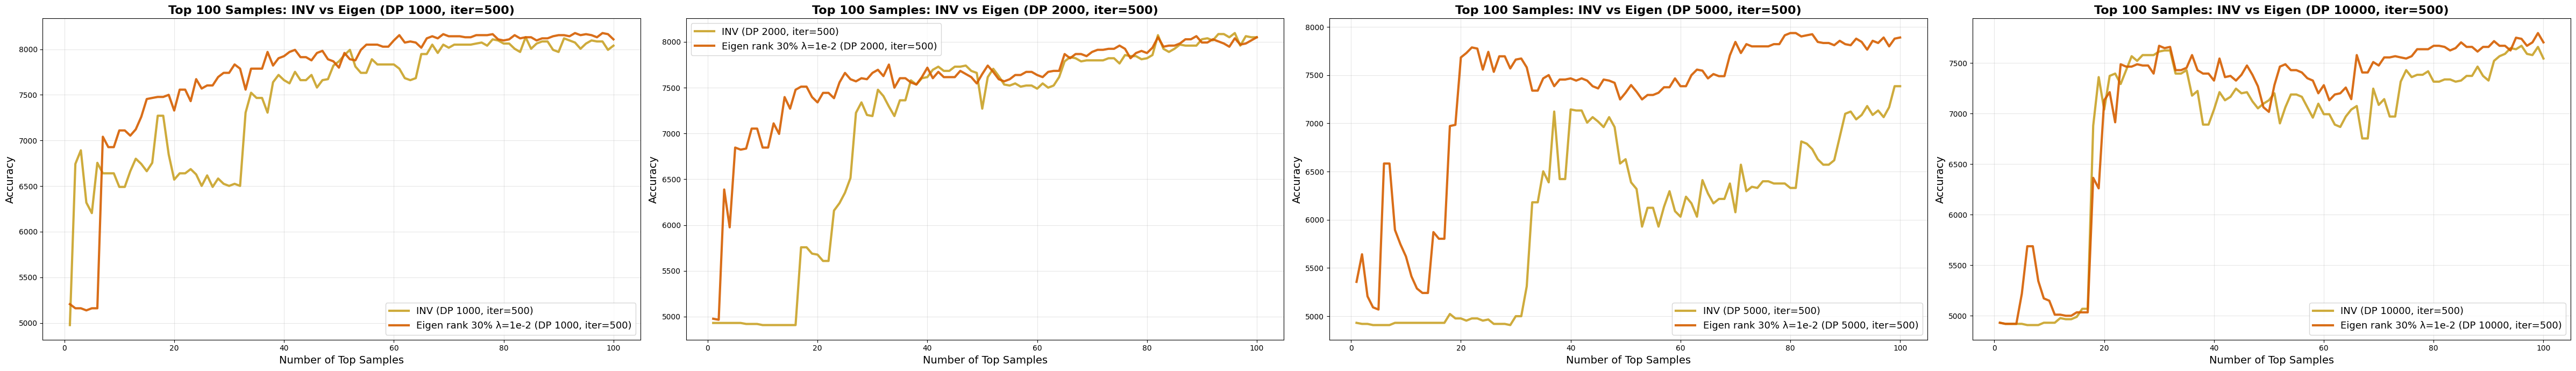

In [ ]:
# top 100 data
data = [i for i in range(1, 101)]
inv_1000              = 
eigen_1000_30_lam1e_2 = 

inv_2000              = 
eigen_2000_30_lam1e_2 = 

inv_5000              = 
eigen_5000_30_lam1e_2 = 

inv_10000              = 
eigen_10000_30_lam1e_2 = 

# Create (1,4) subplots
fig, axes = plt.subplots(1, 4, figsize=(48, 7))

# Color settings
inv_color = '#C9A227'
eigen_color = '#D55E00'  # Orange-red for eigen

# ===== Subplot (1,1): DP 1000 =====
ax_1000 = axes[0]

# Plot INV data (num_dp=1000)
ax_1000.plot(data, inv_1000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 1000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=1000, rank=30%, lambda=1e-2)
ax_1000.plot(data, eigen_1000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 1000, iter=500)', alpha=0.9)

ax_1000.set_xlabel('Number of Top Samples', fontsize=14)
ax_1000.set_ylabel('Accuracy', fontsize=14)
ax_1000.set_title('Top 100 Samples: INV vs Eigen (DP 1000, iter=500)', fontsize=16, fontweight='bold')
ax_1000.legend(fontsize=13, loc='best')
ax_1000.grid(True, alpha=0.3)

# ===== Subplot (1,2): DP 2000 =====
ax_2000 = axes[1]

# Plot INV data (num_dp=2000)
ax_2000.plot(data, inv_2000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 2000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=2000, rank=30%, lambda=1e-2)
ax_2000.plot(data, eigen_2000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 2000, iter=500)', alpha=0.9)

ax_2000.set_xlabel('Number of Top Samples', fontsize=14)
ax_2000.set_ylabel('Accuracy', fontsize=14)
ax_2000.set_title('Top 100 Samples: INV vs Eigen (DP 2000, iter=500)', fontsize=16, fontweight='bold')
ax_2000.legend(fontsize=13, loc='best')
ax_2000.grid(True, alpha=0.3)

# ===== Subplot (1,3): DP 5000 =====
ax_5000 = axes[2]

# Plot INV data (num_dp=5000)
ax_5000.plot(data, inv_5000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 5000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=5000, rank=30%, lambda=1e-2)
ax_5000.plot(data, eigen_5000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 5000, iter=500)', alpha=0.9)

ax_5000.set_xlabel('Number of Top Samples', fontsize=14)
ax_5000.set_ylabel('Accuracy', fontsize=14)
ax_5000.set_title('Top 100 Samples: INV vs Eigen (DP 5000, iter=500)', fontsize=16, fontweight='bold')
ax_5000.legend(fontsize=13, loc='best')
ax_5000.grid(True, alpha=0.3)

# ===== Subplot (1,4): DP 10000 =====
ax_10000 = axes[3]

# Plot INV data (num_dp=10000)
ax_10000.plot(data, inv_10000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 10000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=10000, rank=30%, lambda=1e-2)
ax_10000.plot(data, eigen_10000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 10000, iter=500)', alpha=0.9)

ax_10000.set_xlabel('Number of Top Samples', fontsize=14)
ax_10000.set_ylabel('Accuracy', fontsize=14)
ax_10000.set_title('Top 100 Samples: INV vs Eigen (DP 10000, iter=500)', fontsize=16, fontweight='bold')
ax_10000.legend(fontsize=13, loc='best')
ax_10000.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()